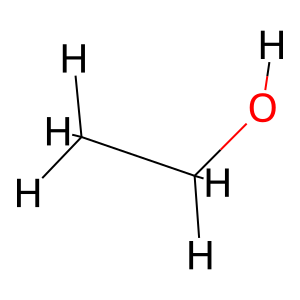

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles("CCO")        # Ethanol
mol = Chem.AddHs(mol)                  # Add hydrogens (important for 3D)
AllChem.EmbedMolecule(mol)             # Generate 3D coordinates
AllChem.UFFOptimizeMolecule(mol)       # Minimize energy with UFF force field

# Visualize 2D structure (you can't see the 3D here, but it's encoded)
Draw.MolToImage(mol)


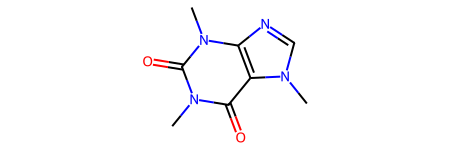

In [2]:
caffeine = Chem.MolFromSmiles('Cn1cnc2c1c(=O)n(C)c(=O)n2C')
caffeine

In [3]:
caffeine
type(caffeine)

rdkit.Chem.rdchem.Mol

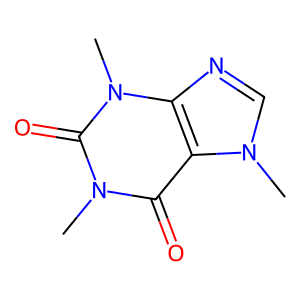

<class 'rdkit.Chem.rdchem.Mol'>


In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Display the molecule
display(Draw.MolToImage(caffeine))

# Print the type below it
print(type(caffeine))



In [5]:
Chem.Draw.MolToFile(caffeine, 'caffeine.svg',
                    size=(500,500),
                    imageType='svg')

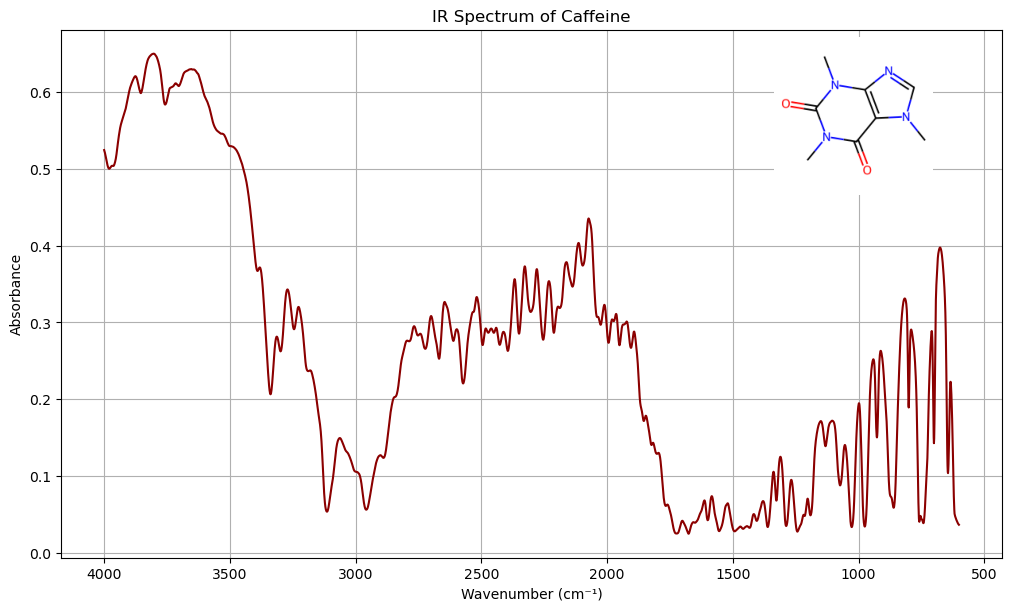

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
from jcamp import jcamp_readfile
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# Create molecule object
caffeine = Chem.MolFromSmiles('Cn1cnc2c1c(=O)n(c(=O)n2C)C')
mol_image = Draw.MolToImage(caffeine, size=(200, 200))

# Read JCAMP-DX spectrum
spectrum = jcamp_readfile('data/caffeine_IR.jdx')
x = np.array(spectrum['x'])
y = np.array(spectrum['y'])

# Ensure x and y are the same length
min_len = min(len(x), len(y))
x = x[:min_len]
y = y[:min_len]

# Filter to 400–4000 cm⁻¹ range
mask = (x >= 400) & (x <= 4000)
x_filtered = x[mask]
y_filtered = y[mask]

# Plot with inset image
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# Plot your main data
ax.plot(x_filtered, y_filtered, color='darkred')
ax.set_xlabel('Wavenumber (cm⁻¹)')
ax.set_ylabel('Absorbance')
ax.set_title('IR Spectrum of Caffeine')
ax.invert_xaxis()
ax.grid(True)

# Add inset axes
ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right')
ax_inset.imshow(mol_image)
ax_inset.axis('off')

plt.show()

In [7]:
import pandas as pd
df = pd.read_csv('data/amino_acid_SMILES.txt', skiprows=2)
df.head()

,name,SMILES
0,alanine,C[C@@H](C(=O)[O-])[NH3+]
1,arginine,[NH3+][C@@H](CCCNC(=[NH2+])N)C(=O)[O-]
2,asparagine,O=C(N)C[C@H]([NH3+])C(=O)[O-]
3,aspartate,C([C@@H](C(=O)[O-])[NH3+])C(=O)[O-]
4,cysteine,C([C@@H](C(=O)[O-])[NH3+])S


In [8]:
AminoAcids = [Chem.MolFromSmiles(SMILES) for SMILES in df['SMILES']]
print(AminoAcids)
print(type(AminoAcids))

[<rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b220>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b290>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b300>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b370>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b3e0>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b450>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b4c0>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b530>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b5a0>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b610>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b680>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b6f0>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b760>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b7d0>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b840>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b8b0>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b920>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02b990>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02ba00>, <rdkit.Chem.rdchem.Mol object at 0x7f1c5f02ba70>]

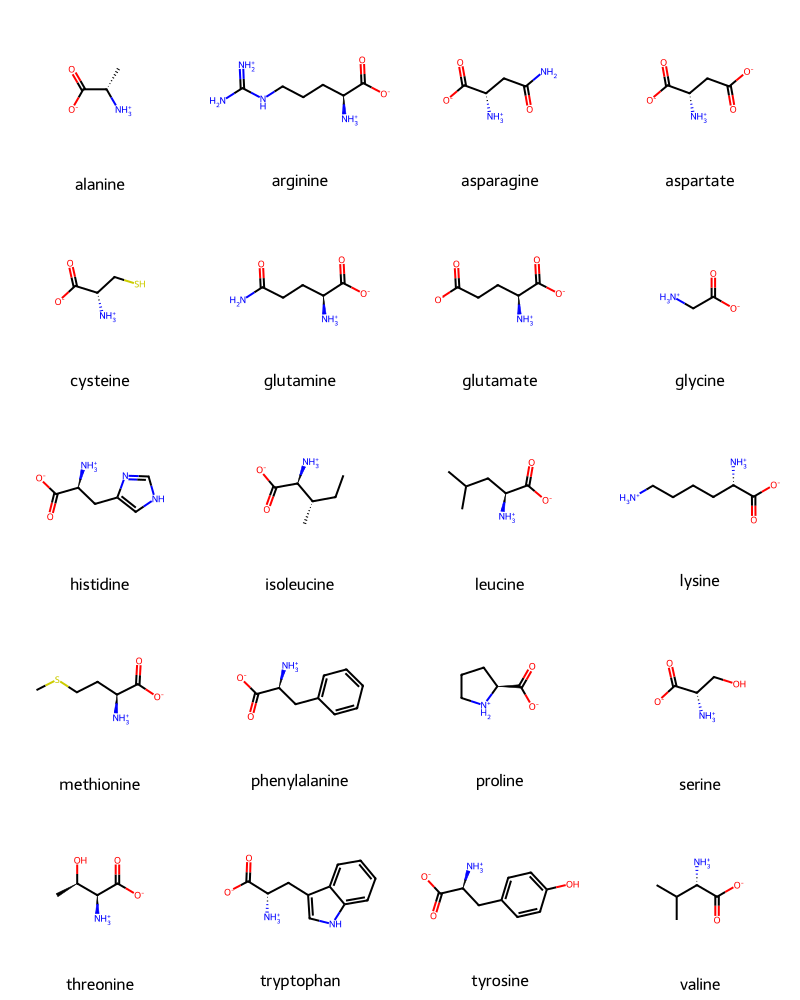

In [9]:
Chem.Draw.MolsToGridImage(AminoAcids, 
                          molsPerRow=4,
                          subImgSize=(200,200),
                          legends=list(df['name']),
                          useSVG=True) 

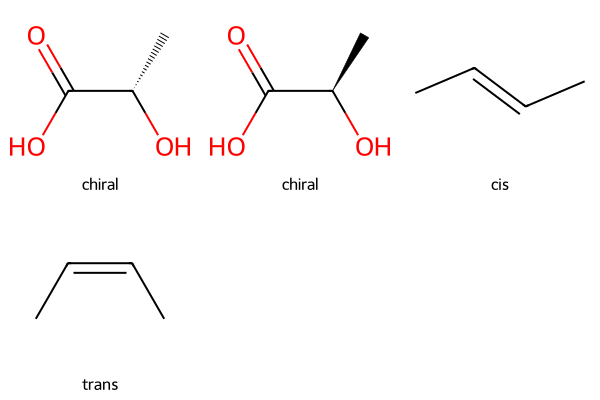

In [10]:
lactic1 = Chem.MolFromSmiles("C[C@H](O)C(=O)O")
lactic2 = Chem.MolFromSmiles("C[C@@H](O)C(=O)O")
#Draw.MolToImage(lactic)

cis_butene = Chem.MolFromSmiles("C/C=C/C")  # cis
trans_butene = Chem.MolFromSmiles("C/C=C\\C")  # trans

Draw.MolsToGridImage([lactic1, lactic2, cis_butene, trans_butene], legends=["chiral", "chiral", "cis", "trans"])

In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
import requests

# Define SMILES strings for the molecules
smiles_list = [
    "C[C@H](O)C(=O)O",    # Lactic acid (R)
    "C[C@@H](O)C(=O)O",   # Lactic acid (S)
    "C/C=C/C",            # cis-2-butene
    "C/C=C\\C"            # trans-2-butene
]

# Convert SMILES strings to RDKit molecule objects
molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
molecules


In [12]:
def get_iupac_name(smiles):
    try:
        url = f"https://cactus.nci.nih.gov/chemical/structure/{smiles}/iupac_name"
        response = requests.get(url)
        response.raise_for_status()
        return response.text
    except requests.RequestException:
        return "IUPAC name not found"

iupac_names = [get_iupac_name(smiles) for smiles in smiles_list]
print(iupac_names)

['(2S)-2-hydroxypropanoic acid', '(2R)-2-hydroxypropanoic acid', '(E)-But-2-ene', '(Z)-But-2-ene']


In [13]:
isomeric_smiles = [Chem.MolToSmiles(mol, isomericSmiles=True) for mol in molecules]


In [14]:
legends = [f"{name}\n{smiles}" for name, smiles in zip(iupac_names, isomeric_smiles)]


In [15]:
# Arrange molecules and legends into a 2x2 grid
mols_matrix = [molecules[:2], molecules[2:]]
legends_matrix = [legends[:2], legends[2:]]


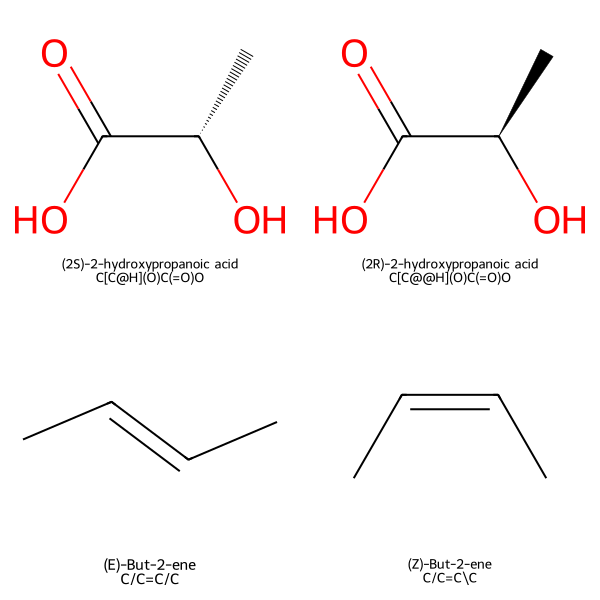

In [16]:
from IPython.display import display

from rdkit.Chem.Draw import MolsMatrixToGridImage

# Generate the grid image
img = MolsMatrixToGridImage(
    molsMatrix=mols_matrix,
    legendsMatrix=legends_matrix,
    subImgSize=(300, 300)
)

# Display the image (in Jupyter Notebook)
#img
display(img)

# To save as image, uncomment the next line
#  img.save("molecule_grid.png")

In [17]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions

# Base SMILES for D-glucose without specified stereochemistry
base_smiles = "OC[C@H]1O[C@H](O)[C@H](O)[C@H](O)[C@H]1O"
base_mol = Chem.MolFromSmiles(base_smiles)

# Set up options to enumerate all stereoisomers
opts = StereoEnumerationOptions(onlyUnassigned=False, unique=True)
isomers = tuple(EnumerateStereoisomers(base_mol, options=opts))


In [18]:
import requests
from rdkit import Chem

def get_iupac_name(smiles):
    try:
        url = f"https://cactus.nci.nih.gov/chemical/structure/{smiles}/iupac_name"
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        return response.text.strip()
    except requests.RequestException:
        return "IUPAC name not found"

# Prepare data for each isomer
isomer_data = []
for mol in isomers:
    smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
    name = get_iupac_name(smiles)
    isomer_data.append((mol, name, smiles))
print(isomer_data)
print(type(isomer_data))
print(f"There are {len(isomer_data)} tuples in this list, meaning there are {len(isomer_data)} isomers." )

[(<rdkit.Chem.rdchem.Mol object at 0x7f1c5fd32110>, '(2S,3R,4R,5S,6S)-6-(hydroxymethyl)oxane-2,3,4,5-tetrol', 'OC[C@@H]1O[C@H](O)[C@H](O)[C@H](O)[C@@H]1O'), (<rdkit.Chem.rdchem.Mol object at 0x7f1c5e9626b0>, '(2S,3R,4R,5S,6R)-6-(hydroxymethyl)oxane-2,3,4,5-tetrol', 'OC[C@H]1O[C@H](O)[C@H](O)[C@H](O)[C@@H]1O'), (<rdkit.Chem.rdchem.Mol object at 0x7f1c5e9627a0>, '(2R,3R,4R,5S,6S)-6-(hydroxymethyl)oxane-2,3,4,5-tetrol', 'OC[C@@H]1O[C@@H](O)[C@H](O)[C@H](O)[C@@H]1O'), (<rdkit.Chem.rdchem.Mol object at 0x7f1c5e962840>, '(2R,3R,4R,5S,6R)-6-(hydroxymethyl)oxane-2,3,4,5-tetrol', 'OC[C@H]1O[C@@H](O)[C@H](O)[C@H](O)[C@@H]1O'), (<rdkit.Chem.rdchem.Mol object at 0x7f1c5e9628e0>, 'IUPAC name not found', 'OC[C@@H]1O[C@H](O)[C@@H](O)[C@H](O)[C@@H]1O'), (<rdkit.Chem.rdchem.Mol object at 0x7f1c5e962980>, '(2S,3S,4R,5S,6R)-6-(hydroxymethyl)oxane-2,3,4,5-tetrol', 'OC[C@H]1O[C@H](O)[C@@H](O)[C@H](O)[C@@H]1O'), (<rdkit.Chem.rdchem.Mol object at 0x7f1c5e962a20>, '(2R,3S,4R,5S,6S)-6-(hydroxymethyl)oxane-2,3,

In [19]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# Define the SMILES string for glucose
smiles = 'OC[C@H]1O[C@H](O)[C@H](O)[C@H](O)[C@H]1O'
mol = Chem.MolFromSmiles(smiles)

# Assign stereochemistry to the molecule
Chem.AssignStereochemistry(mol, force=True, cleanIt=True)

# Find chiral centers
chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
print(f"Chiral centers: {chiral_centers}")

# Prepare the molecule for drawing
drawer = rdMolDraw2D.MolDraw2DCairo(500, 500)
drawer.drawOptions().addAtomIndices = True
drawer.drawOptions().addStereoAnnotation = True
rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
drawer.FinishDrawing()

# Save the image
with open('glucose_chiral_centers.png', 'wb') as f:
    f.write(drawer.GetDrawingText())


Chiral centers: [(2, 'R'), (4, 'S'), (6, 'R'), (8, 'R'), (10, 'R')]


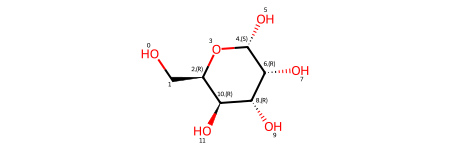

In [20]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

# Enable SVG rendering in Jupyter
IPythonConsole.ipython_useSVG = True
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.drawOptions.addStereoAnnotation = True

# Define the SMILES string for D-glucose
smiles = 'OC[C@H]1O[C@H](O)[C@H](O)[C@H](O)[C@H]1O'
mol = Chem.MolFromSmiles(smiles)

# Display the molecule
mol


In [21]:
from rdkit.Chem import Draw

# Extract molecules and legends
mols = [data[0] for data in isomer_data]
legends = [f"{data[1]}\n{data[2]}" for data in isomer_data]

# Generate and display the grid image
img = Draw.MolsToGridImage(mols, legends=legends, molsPerRow=4, subImgSize=(200, 200))
img


In [22]:
from rdkit.Chem import Draw

# Extract molecules and legends
mols = [data[0] for data in isomer_data]
legends = [f"{data[1]}\n{data[2]}" for data in isomer_data]

# Generate and display the grid image
img = Draw.MolsToGridImage(mols, legends=legends, molsPerRow=4, subImgSize=(200, 200))
img


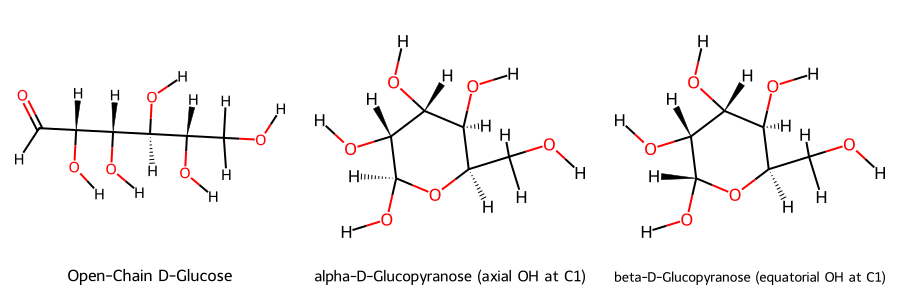

In [23]:
from rdkit import Chem
from rdkit.Chem import Draw

# Explicitly defined stereochemistry
smiles_open_chain = "OC[C@H](O)[C@H](O)[C@H](O)[C@H](O)C=O"
smiles_alpha = "OC[C@H]1O[C@@H](O)[C@H](O)[C@H](O)[C@H]1O"  # α-D-glucopyranose
smiles_beta = "OC[C@H]1O[C@H](O)[C@H](O)[C@H](O)[C@H]1O"   # β-D-glucopyranose

mols = [Chem.MolFromSmiles(smi) for smi in [smiles_open_chain, smiles_alpha, smiles_beta]]

# Optional: add hydrogens for better 2D layout
mols = [Chem.AddHs(mol) for mol in mols]

# Generate image
Draw.MolsToImage(mols, legends=[
    "Open-Chain D-Glucose",
    "alpha-D-Glucopyranose (axial OH at C1)",
    "beta-D-Glucopyranose (equatorial OH at C1)"
], subImgSize=(300, 300))


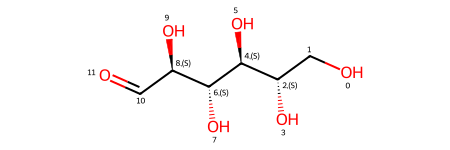

In [24]:
open_chain_smiles = 'OC[C@H](O)[C@H](O)[C@H](O)[C@H](O)C=O'
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

# Enable SVG rendering in Jupyter
IPythonConsole.ipython_useSVG = True

# Create the molecule from the SMILES string
mol = Chem.MolFromSmiles(open_chain_smiles)

# Display the molecule
mol


In [25]:
from rdkit import Chem
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions

# Define the open-chain SMILES for D-glucose
open_chain_smiles = 'OC[C@H](O)[C@H](O)[C@H](O)[C@H](O)C=O'
mol = Chem.MolFromSmiles(open_chain_smiles)

# Set up stereoisomer enumeration options
opts = StereoEnumerationOptions(onlyUnassigned=False, unique=True)

# Generate stereoisomers
stereoisomers = tuple(EnumerateStereoisomers(mol, options=opts))

print(f"Number of open-chain stereoisomers generated: {len(stereoisomers)}")


Number of open-chain stereoisomers generated: 16


In [26]:
from rdkit import Chem
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions

# Define the open-chain SMILES for D-glucose
open_chain_smiles = 'OC[C@H](O)[C@H](O)[C@H](O)[C@H](O)C=O'
mol = Chem.MolFromSmiles(open_chain_smiles)

# Set up stereoisomer enumeration options
opts = StereoEnumerationOptions(onlyUnassigned=False, unique=True)

# Generate stereoisomers
stereoisomers = tuple(EnumerateStereoisomers(mol, options=opts))

print(f"Number of open-chain stereoisomers generated: {len(stereoisomers)}")


Number of open-chain stereoisomers generated: 16


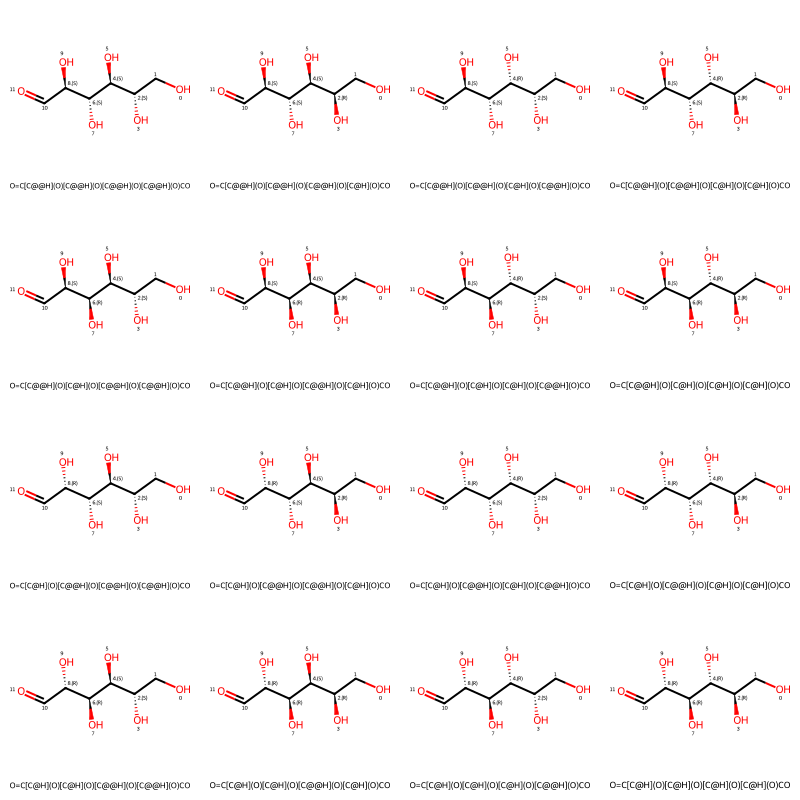

In [27]:
from rdkit.Chem import Draw

# Generate images with SMILES as legends
images = [Chem.MolToSmiles(mol, isomericSmiles=True) for mol in stereoisomers]

# Create a grid image
img = Draw.MolsToGridImage(stereoisomers, molsPerRow=4, subImgSize=(200, 200), legends=images)

# Display the image
img


In [28]:
from rdkit.Chem import Descriptors

# Access the list of descriptor name-function pairs
descriptor_list = Descriptors._descList

# Display the total number of descriptors
print(f"Total descriptors available: {len(descriptor_list)}\n")

# Print the first 10 descriptors as an example
for name, func in descriptor_list[:10]:
    print(f"{name}: {func}")


Total descriptors available: 217

MaxAbsEStateIndex: <function MaxAbsEStateIndex at 0x7f1c5e1536d0>
MaxEStateIndex: <function MaxEStateIndex at 0x7f1c5e1535b0>
MinAbsEStateIndex: <function MinAbsEStateIndex at 0x7f1c5e153760>
MinEStateIndex: <function MinEStateIndex at 0x7f1c5e153640>
qed: <function qed at 0x7f1c5e25a560>
SPS: <function SPS at 0x7f1c5e25a9e0>
MolWt: <function <lambda> at 0x7f1c5e25b010>
HeavyAtomMolWt: <function HeavyAtomMolWt at 0x7f1c5e25b0a0>
ExactMolWt: <function <lambda> at 0x7f1c5e25b130>
NumValenceElectrons: <function NumValenceElectrons at 0x7f1c5e25b1c0>


In [29]:
# List all descriptor names
descriptor_names = [name for name, _ in Descriptors._descList]
print(len(descriptor_names))
print(descriptor_names)


217
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10'

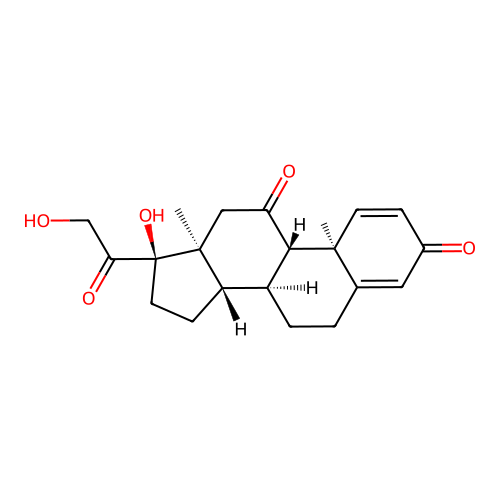

In [30]:
ptx = Chem.MolFromSmiles('[H][C@@]12CC[C@](O)(C(=O)CO)[C@@]1(C)CC(=O)[C@@]1([H])[C@@]2([H])CCC2=CC(=O)C=C[C@]12C')
Chem.Draw.MolToImage(ptx, size=(500,500))

In [31]:
import urllib.parse

smiles = "[H][C@@]12CC[C@](O)(C(=O)CO)[C@@]1(C)CC(=O)[C@@]1([H])[C@@]2([H])CCC2=CC(=O)C=C[C@]12C"
encoded_smiles = urllib.parse.quote(smiles)

print(encoded_smiles)


%5BH%5D%5BC%40%40%5D12CC%5BC%40%5D%28O%29%28C%28%3DO%29CO%29%5BC%40%40%5D1%28C%29CC%28%3DO%29%5BC%40%40%5D1%28%5BH%5D%29%5BC%40%40%5D2%28%5BH%5D%29CCC2%3DCC%28%3DO%29C%3DC%5BC%40%5D12C


In [32]:
import requests
requests.get("https://cactus.nci.nih.gov/chemical/structure/aspirin/iupac_name")

<Response [200]>